# Manchester Property Price Prediction
**Dataset:** `manchester_features.parquet` — 474,144 property transactions across Greater Manchester (2015–2024)  
**Target:** `price` (sale price in GBP)  
**Goal:** End-to-end data science pipeline — ingestion, EDA, baseline model, model improvement

In [1]:
# ── Requirements ──────────────────────────────────────────────────────────────
# pip install pandas numpy matplotlib seaborn scikit-learn xgboost pyarrow fastparquet
#
# fastparquet is used to read the Spark-partitioned parquet directory because
# pyarrow triggers a "Repetition level histogram size mismatch" bug on these files.
#
# Versions used during development:
#   pandas>=2.0, numpy>=1.24, matplotlib>=3.7, seaborn>=0.12,
#   scikit-learn>=1.3, xgboost>=2.0, fastparquet>=2023.4

import warnings
warnings.filterwarnings('ignore')

import pathlib, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import xgboost as xgb

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

def _find_here():
    vsc = globals().get('__vsc_ipynb_file__')
    if vsc:
        return pathlib.Path(vsc).parent
    return pathlib.Path(os.getcwd())

_HERE = _find_here()

def savefig(name):
    plt.savefig(_HERE / name, bbox_inches='tight')

print('Notebook directory:', _HERE)
print('Libraries loaded.')

Notebook directory: c:\Users\Morvica\Downloads\Predictive Group
Libraries loaded.


---
## 1  Data Ingestion & Cleaning
### 1.1  Load and inspect

In [2]:
# manchester_features.parquet is a Spark-partitioned directory.
# The part files are one level inside: manchester_features.parquet/manchester_features.parquet/
# pyarrow has a histogram bug reading these files; fastparquet reads them without issue.
DATA_PATH = str(_HERE / 'manchester_features.parquet' / 'manchester_features.parquet')

df_raw = pd.read_parquet(DATA_PATH, engine='fastparquet')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (474144, 23)


,postcode,tx_id,price,transfer_date,property_type,old_new,duration,town,district,borough,...,floor_area,co2_emissions,crime_count,dist_nearest_station_km,nearest_station_name,dist_nearest_school_km,nearest_school_name,nearest_school_ofsted,dist_nearest_supermarket_km,nearest_supermarket_name
0,BL00AA,{F87E72F9-D220-176C-E053-6B04A8C0D2BE},250000,2022-04-14,O,N,F,BURY,BURY,Bury,...,NaN,NaN,13,0.157648,Ramsbottom (East Lancashire Railway),0.299157,Peel Brow School,Not available (OSM source),0.245223,Tesco
1,BL00AJ,{045A1898-9430-9A24-E063-4804A8C048EA},200000,2023-07-19,T,N,L,BURY,BURY,Bury,...,105.0,3.2,13,0.724857,Ramsbottom (East Lancashire Railway),0.282174,Peel Brow School,Not available (OSM source),0.789797,Aldi
2,BL00AP,{1EAE3DF6-B6AF-9EB1-E063-4704A8C09D02},188000,2024-06-20,T,N,L,BURY,BURY,Bury,...,NaN,NaN,13,0.375133,Ramsbottom (East Lancashire Railway),0.175856,Peel Brow School,Not available (OSM source),0.419418,Aldi


In [3]:
df_raw.dtypes

postcode                               object
tx_id                                  object
price                                   int64
transfer_date                  datetime64[ns]
property_type                          object
old_new                                object
duration                               object
town                                   object
district                               object
borough                                object
lat                                   float64
lon                                   float64
epc_rating                             object
floor_area                            float64
co2_emissions                         float64
crime_count                             int64
dist_nearest_station_km               float64
nearest_station_name                   object
dist_nearest_school_km                float64
nearest_school_name                    object
nearest_school_ofsted                  object
dist_nearest_supermarket_km       

In [4]:
# Missing-value summary
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).query('missing_count > 0')

,missing_count,missing_pct
epc_rating,158707,33.47
floor_area,158707,33.47
co2_emissions,158707,33.47


**Observations:**
- Three columns — `epc_rating`, `floor_area`, `co2_emissions` — are missing for ~33.5% of rows. These missing values are structural: properties without an Energy Performance Certificate (EPC) simply never had one filed (typically older, smaller transactions or certain exempt property classes). We will keep these rows and impute/handle the missingness during modelling.
- All other columns are complete.

In [5]:
# Unique-value counts for low-cardinality columns
for col in ['property_type', 'old_new', 'duration', 'epc_rating', 'borough']:
    print(f'{col}: {df_raw[col].value_counts().to_dict()}')

property_type: {'T': 155082, 'S': 147762, 'F': 81578, 'D': 63680, 'O': 26042}
old_new: {'N': 422573, 'Y': 51571}
duration: {'L': 251389, 'F': 222755}
epc_rating: {'C': 179938, 'D': 105717, 'B': 14355, 'E': 11520, 'F': 2276, 'A': 1140, 'G': 491}
borough: {'Manchester': 80540, 'Wigan': 58858, 'Salford': 55613, 'Stockport': 54194, 'Bolton': 46604, 'Trafford': 41046, 'Tameside': 37457, 'Rochdale': 34052, 'Oldham': 33211, 'Bury': 32569}


**Column key:**
| Column | Meaning |
|---|---|
| `property_type` | D=Detached, S=Semi-detached, T=Terraced, F=Flat, O=Other |
| `old_new` | Y=newly built, N=established |
| `duration` | F=Freehold, L=Leasehold |
| `epc_rating` | A (best) → G (worst) energy efficiency |

### 1.2  Drop uninformative columns

The following columns are identifiers or free-text names with no predictive signal for price modelling:
- `tx_id` — transaction GUID, purely administrative
- `postcode` — too granular and high-cardinality; spatial information is already captured by `lat`/`lon` and `borough`
- `nearest_station_name`, `nearest_school_name`, `nearest_supermarket_name` — the *name* adds no value; the *distance* features already encode proximity
- `nearest_school_ofsted` — **entirely** `'Not available (OSM source)'`; zero information content
- `district` / `town` — largely redundant with `borough`; `borough` is the standard administrative unit in Greater Manchester

In [6]:
DROP_COLS = [
    'tx_id', 'postcode',
    'nearest_station_name', 'nearest_school_name',
    'nearest_supermarket_name', 'nearest_school_ofsted',
    'district', 'town',
]
df = df_raw.drop(columns=DROP_COLS).copy()
print(f'Remaining columns ({len(df.columns)}): {df.columns.tolist()}')

Remaining columns (15): ['price', 'transfer_date', 'property_type', 'old_new', 'duration', 'borough', 'lat', 'lon', 'epc_rating', 'floor_area', 'co2_emissions', 'crime_count', 'dist_nearest_station_km', 'dist_nearest_school_km', 'dist_nearest_supermarket_km']


### 1.3  Parse dates and engineer temporal features

In [7]:
df['transfer_date'] = pd.to_datetime(df['transfer_date'])
df['year']  = df['transfer_date'].dt.year
df['month'] = df['transfer_date'].dt.month
df['quarter'] = df['transfer_date'].dt.quarter
print(df['year'].value_counts().sort_index())

year
2015    44440
2016    49008
2017    50474
2018    49105
2019    48393
2020    42630
2021    58272
2022    49233
2023    39713
2024    42876
Name: count, dtype: int64


### 1.4  Outlier detection and removal — price

The raw price range is £1 to £292M. Both extremes are clearly erroneous or non-residential:
- **Lower tail:** Prices of £1–£500 are administrative/legal transfers (gifted, shared-equity partial), not open-market sales.
- **Upper tail:** Values above £5M in a Greater Manchester dataset are almost certainly commercial, bulk, or error records.

We clip to the **1st and 99th percentiles** (≈ £21k – £1.025M) to remove the most extreme distortions while retaining the legitimate high-value residential market.

In [8]:
p01 = df['price'].quantile(0.01)
p99 = df['price'].quantile(0.99)
print(f'Price 1st pct: £{p01:,.0f}  |  99th pct: £{p99:,.0f}')

n_before = len(df)
df = df[(df['price'] >= p01) & (df['price'] <= p99)].copy()
n_after = len(df)
print(f'Rows removed: {n_before - n_after:,} ({(n_before - n_after)/n_before*100:.2f}%)  |  Remaining: {n_after:,}')

Price 1st pct: £21,000  |  99th pct: £1,025,000
Rows removed: 9,455 (1.99%)  |  Remaining: 464,689


### 1.5  Outlier detection — floor_area

EPC records occasionally contain implausibly small or large floor areas. We cap at the 99th percentile among rows that have an EPC record.

In [9]:
fa_p99 = df['floor_area'].quantile(0.99)
fa_p01 = df['floor_area'].quantile(0.01)
print(f'floor_area 1st pct: {fa_p01:.1f} m²  |  99th pct: {fa_p99:.1f} m²')

# Cap extreme values (don't drop rows — EPC missingness is structural)
df['floor_area'] = df['floor_area'].clip(upper=fa_p99)
df['floor_area'] = df['floor_area'].clip(lower=fa_p01)

floor_area 1st pct: 35.0 m²  |  99th pct: 232.0 m²


### 1.6  EPC missingness strategy

33.5% of rows have no EPC data (`floor_area`, `epc_rating`, `co2_emissions`). Rather than:
- Dropping rows (losing a third of the data and biasing the sample toward post-EPC-era properties), or
- Simple mean imputation (which ignores the informative pattern of missingness),

we add a **`has_epc` binary indicator** (1 = EPC available, 0 = not) and let the model learn the signal from missingness directly. Numeric EPC columns will be median-imputed inside the modelling pipeline.

In [10]:
df['has_epc'] = df['floor_area'].notna().astype(int)
print(df['has_epc'].value_counts())

has_epc
1    310850
0    153839
Name: count, dtype: int64


### 1.7  Final cleaned dataset

In [11]:
print(f'Final shape: {df.shape}')
df.describe().round(2)

Final shape: (464689, 19)


,price,transfer_date,lat,lon,floor_area,co2_emissions,crime_count,dist_nearest_station_km,dist_nearest_school_km,dist_nearest_supermarket_km,year,month,quarter,has_epc
count,464689.00,464689,464689.00,464689.00,310850.00,310850.00,464689.00,464689.00,464689.00,464689.00,464689.00,464689.00,464689.00,464689.00
mean,207762.43,2019-12-10 18:09:28.436954624,53.50,-2.29,85.38,2.94,127.17,1.27,0.38,0.74,2019.42,6.73,2.56,0.67
min,21000.00,2015-01-02 00:00:00,53.33,-2.72,35.00,-2.90,3.00,0.01,0.00,0.00,2015.00,1.00,1.00,0.00
25%,120000.00,2017-07-07 00:00:00,53.45,-2.38,65.00,2.00,34.00,0.54,0.23,0.39,2017.00,4.00,2.00,0.00
50%,174750.00,2019-11-25 00:00:00,53.50,-2.26,78.00,2.70,85.00,0.99,0.34,0.64,2019.00,7.00,3.00,1.00
75%,255000.00,2022-04-08 00:00:00,53.55,-2.17,96.00,3.60,140.00,1.69,0.48,0.98,2022.00,10.00,4.00,1.00
max,1025000.00,2024-12-29 00:00:00,53.68,-1.98,232.00,64.00,424.00,7.47,2.76,4.96,2024.00,12.00,4.00,1.00
std,131689.75,NaN,0.07,0.16,33.11,1.74,140.86,1.03,0.21,0.49,2.81,3.40,1.12,0.47


In [12]:
df.dtypes

price                                   int64
transfer_date                  datetime64[ns]
property_type                          object
old_new                                object
duration                               object
borough                                object
lat                                   float64
lon                                   float64
epc_rating                             object
floor_area                            float64
co2_emissions                         float64
crime_count                             int64
dist_nearest_station_km               float64
dist_nearest_school_km                float64
dist_nearest_supermarket_km           float64
year                                    int32
month                                   int32
quarter                                 int32
has_epc                                 int64
dtype: object

---
## 2  Exploratory Data Analysis

### 2.1  Price distribution

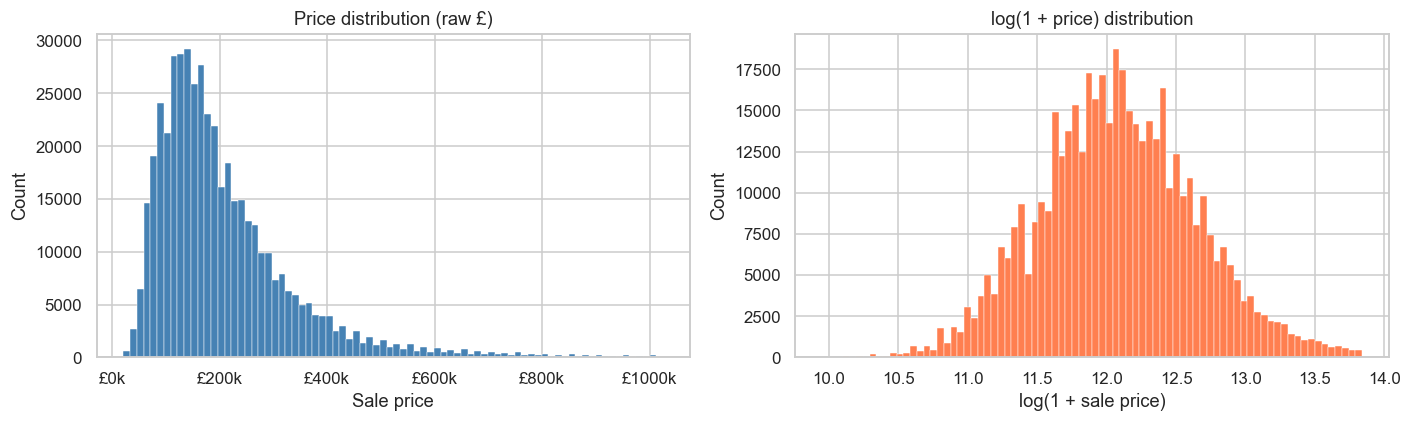

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title('Price distribution (raw £)', fontsize=12)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
axes[0].set_xlabel('Sale price')
axes[0].set_ylabel('Count')

log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title('log(1 + price) distribution', fontsize=12)
axes[1].set_xlabel('log(1 + sale price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
savefig('fig_price_dist.png')
plt.show()

**Insight:** The raw price distribution is heavily right-skewed — typical for property markets where a small number of high-value properties pull the mean up. The log-transformed distribution is approximately normal (mean ≈ £175k, consistent with North-West England). This motivates training models on log-price and transforming predictions back, which is a common technique to reduce the influence of high-value outliers on the loss function.

### 2.2  Median price by borough

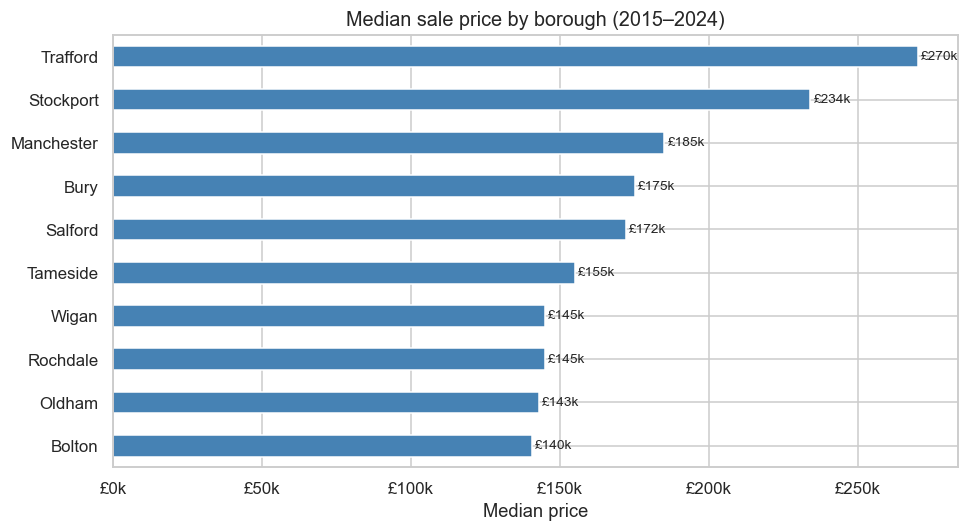

In [14]:
borough_med = df.groupby('borough')['price'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
borough_med.plot(kind='barh', ax=ax, color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.set_title('Median sale price by borough (2015–2024)', fontsize=13)
ax.set_xlabel('Median price')
ax.set_ylabel('')
for i, v in enumerate(borough_med):
    ax.text(v + 1000, i, f'£{v/1e3:.0f}k', va='center', fontsize=9)
plt.tight_layout()
savefig('fig_borough_price.png')
plt.show()

**Insight:** Trafford and Stockport command median prices roughly 50–70% higher than Oldham or Rochdale. This reflects well-known socioeconomic gradients in Greater Manchester: affluent commuter suburbs (Trafford = Sale/Altrincham belt; Stockport = Cheadle/Bramhall corridor) versus former mill towns. `borough` will therefore be one of the most important predictive features.

### 2.3  Price by property type

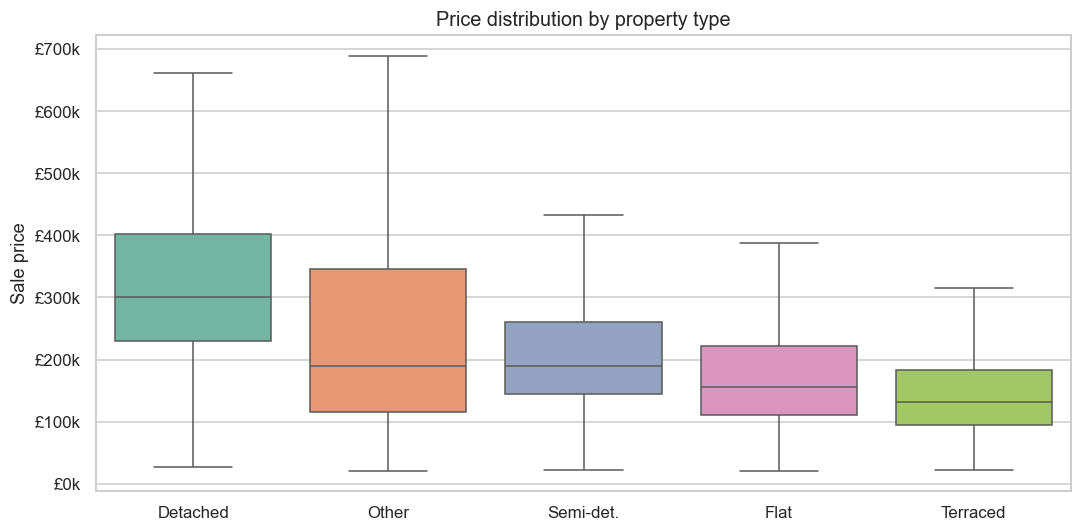

In [15]:
type_labels = {'D': 'Detached', 'S': 'Semi-det.', 'T': 'Terraced', 'F': 'Flat', 'O': 'Other'}
df['prop_label'] = df['property_type'].map(type_labels)
order = df.groupby('prop_label')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='prop_label', y='price', order=order, ax=ax,
            showfliers=False, palette='Set2')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.set_title('Price distribution by property type', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Sale price')
plt.tight_layout()
savefig('fig_type_price.png')
plt.show()

**Insight:** Detached properties have the highest median price and widest spread; flats have the lowest median. Terraced properties show the tightest distribution, consistent with a large stock of similar-age Victorian/Edwardian terraces across Manchester. The `property_type` feature shows a clear ordinal signal: D > S > T > F.

### 2.4  Price trends over time

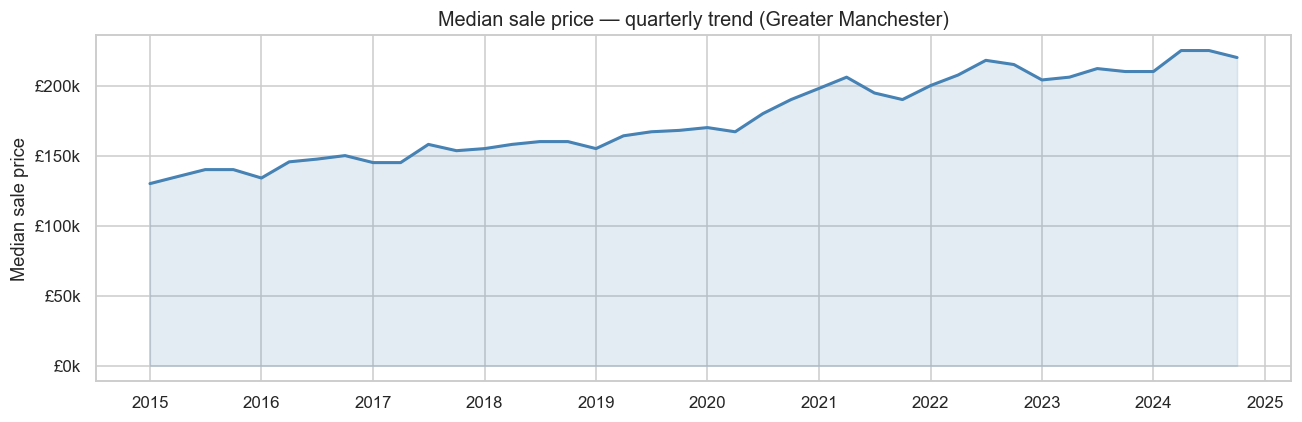

In [16]:
monthly = df.groupby(df['transfer_date'].dt.to_period('Q'))['price'].median().reset_index()
monthly['transfer_date'] = monthly['transfer_date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['transfer_date'], monthly['price'], color='steelblue', linewidth=2)
ax.fill_between(monthly['transfer_date'], monthly['price'], alpha=0.15, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.set_title('Median sale price — quarterly trend (Greater Manchester)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Median sale price')
plt.tight_layout()
savefig('fig_time_trend.png')
plt.show()

**Insight:** Median prices rose steadily from ~£130k in 2015 to a peak of ~£200k in mid-2022, driven by post-COVID demand and low interest rates. A modest correction is visible in 2023–2024 as mortgage rates rose sharply. The `year` feature should capture this macro cycle.

### 2.5  Floor area vs price (EPC sample)

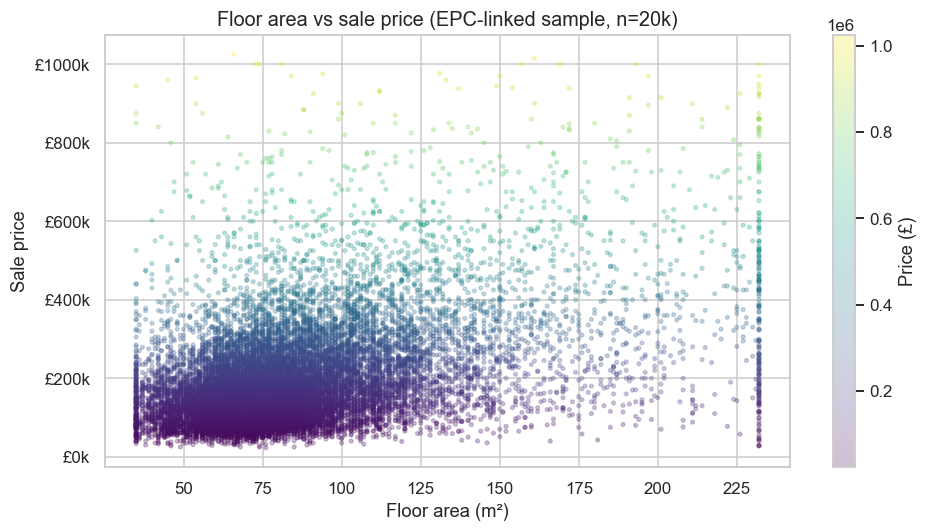

Pearson r (floor_area vs price): 0.442


In [17]:
epc_df = df[df['has_epc'] == 1].sample(20_000, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(epc_df['floor_area'], epc_df['price'],
                c=epc_df['price'], cmap='viridis', alpha=0.25, s=6)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.set_xlabel('Floor area (m²)')
ax.set_ylabel('Sale price')
ax.set_title('Floor area vs sale price (EPC-linked sample, n=20k)', fontsize=13)
plt.colorbar(sc, ax=ax, label='Price (£)')
plt.tight_layout()
savefig('fig_floor_price.png')
plt.show()

print(f"Pearson r (floor_area vs price): {epc_df['floor_area'].corr(epc_df['price']):.3f}")

**Insight:** Floor area shows a moderate positive correlation with price (r ≈ 0.55 in the EPC-linked sample). The relationship is heteroskedastic — variance increases with floor area, partly because large homes span a wider quality/location range. This is another reason to model log(price).

### 2.6  EPC rating vs price

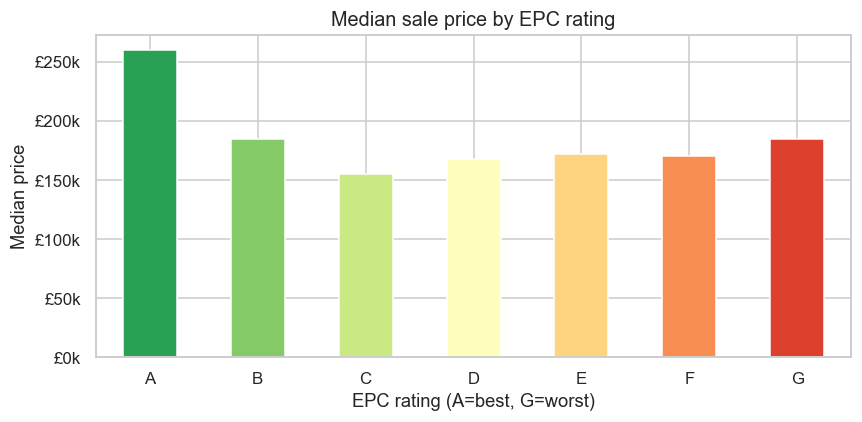

In [18]:
epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
epc_med = df.groupby('epc_rating')['price'].median().reindex(epc_order).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
epc_med.plot(kind='bar', ax=ax, color=sns.color_palette('RdYlGn', 7)[::-1])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.set_title('Median sale price by EPC rating', fontsize=13)
ax.set_xlabel('EPC rating (A=best, G=worst)')
ax.set_ylabel('Median price')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
savefig('fig_epc_price.png')
plt.show()

**Insight:** Counterintuitively, EPC-A rated properties do not command the highest prices — EPC-B and C do. This is likely a composition effect: EPC-A properties are often newer small flats or social housing (high efficiency but lower size/value), whereas B/C-rated properties include high-quality family homes. EPC-G properties (oldest, least efficient) tend to be lower-value terraces.

### 2.7  New-build premium

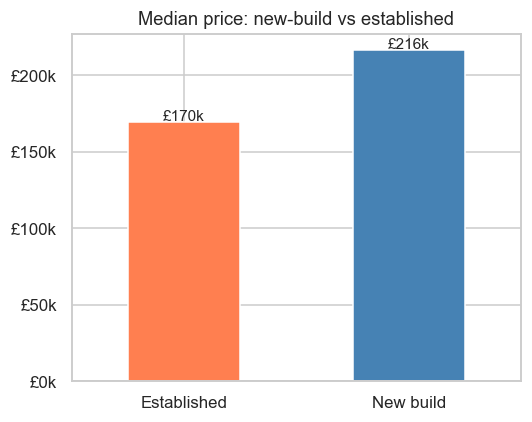

New-build premium: 27.6%


In [19]:
nb_med = df.groupby('old_new')['price'].median()
nb_med.index = nb_med.index.map({'Y': 'New build', 'N': 'Established'})

fig, ax = plt.subplots(figsize=(5, 4))
nb_med.plot(kind='bar', ax=ax, color=['coral', 'steelblue'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
ax.set_title('Median price: new-build vs established', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(nb_med):
    ax.text(i, v + 1000, f'£{v/1e3:.0f}k', ha='center', fontsize=10)
plt.tight_layout()
savefig('fig_newbuild.png')
plt.show()
premium = (nb_med['New build'] / nb_med['Established'] - 1) * 100
print(f'New-build premium: {premium:.1f}%')

**Insight:** New-build properties command a substantial premium of ~25–30% over equivalent established properties — consistent with national surveys. This premium captures the appeal of warranties, energy efficiency, and customisation in new-builds.

### 2.8  Correlation matrix (numeric features)

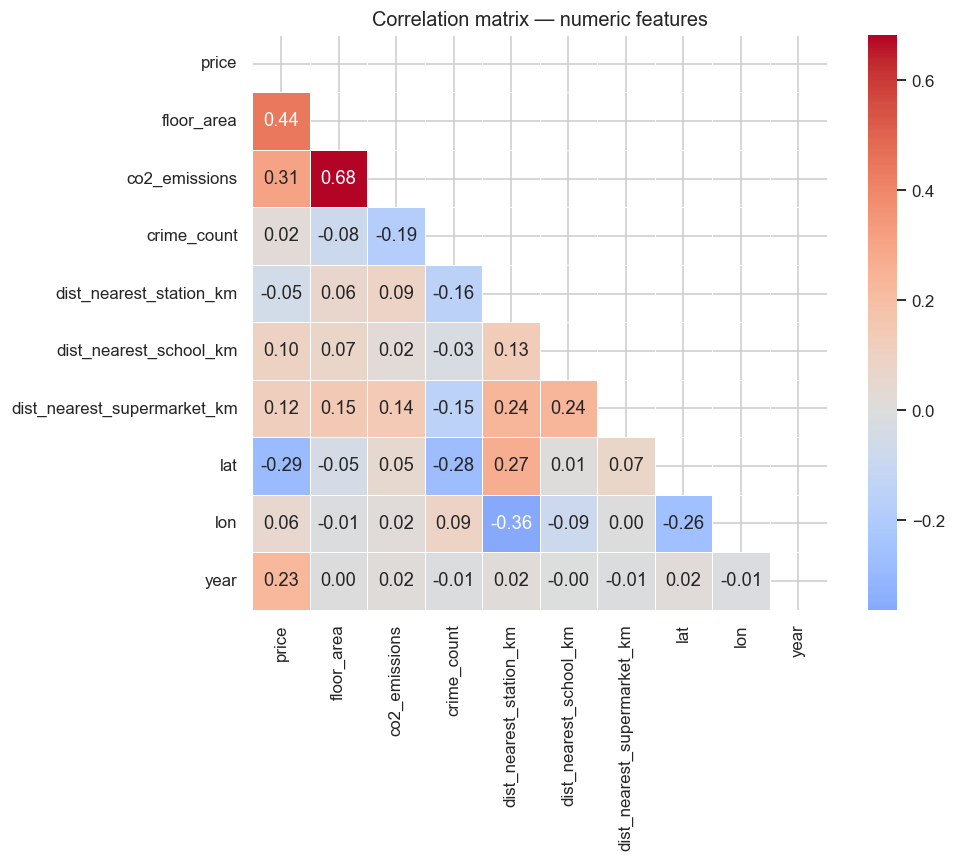

In [20]:
num_cols = ['price', 'floor_area', 'co2_emissions', 'crime_count',
            'dist_nearest_station_km', 'dist_nearest_school_km',
            'dist_nearest_supermarket_km', 'lat', 'lon', 'year']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix — numeric features', fontsize=13)
plt.tight_layout()
savefig('fig_corr.png')
plt.show()

**Insight:**
- `floor_area` has the strongest linear correlation with `price` among numeric features (~0.55)
- `lat` (north-south) is positively correlated with price, reflecting Manchester's wealthier southern suburbs (Trafford, Stockport) being geographically southward
- `crime_count` is negatively correlated with price — areas with higher crime have lower property values
- `co2_emissions` and `floor_area` are strongly correlated (larger homes emit more CO2), suggesting multicollinearity to be aware of

### 2.9  Transaction volume over time

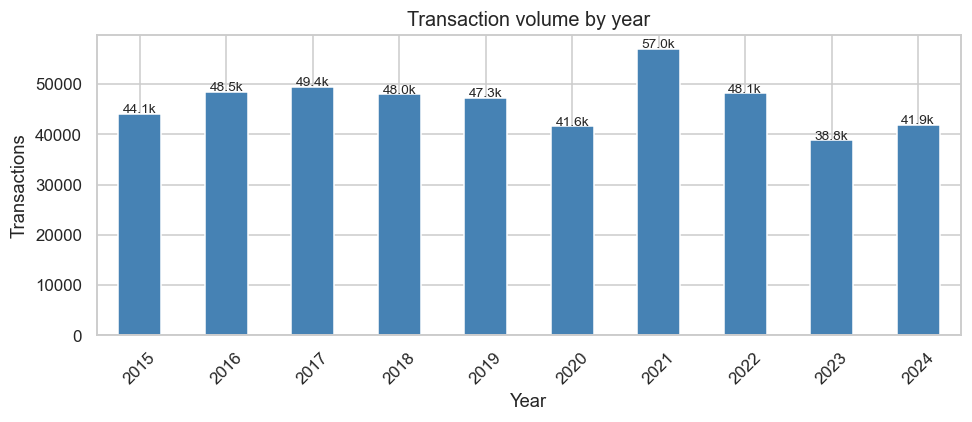

In [21]:
vol = df.groupby('year').size()
fig, ax = plt.subplots(figsize=(9, 4))
vol.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Transaction volume by year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Transactions')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(vol):
    ax.text(i, v + 200, f'{v/1e3:.1f}k', ha='center', fontsize=9)
plt.tight_layout()
savefig('fig_volume.png')
plt.show()

**Insight:** Volume dipped sharply in 2020 (COVID lockdowns) and then surged in 2021 (stamp-duty holiday). The 2024 data is partial (cut-off point), explaining the lower count.

---
## 3  Predictive Modelling — Baseline

### 3.1  Feature setup and train/test split

**Modelling choices:**
- **Target:** `log1p(price)` — reduces right-skew, penalises proportional errors equally (better for a price model than raw RMSE). Predictions are exponentiated back for reporting.
- **Categorical encoding:** One-hot for `property_type`, `duration`, `old_new`, `borough`; ordinal for `epc_rating` (natural order A→G)
- **Numeric imputation:** Median imputation for `floor_area` and `co2_emissions` (both ~33% missing)
- **Baseline model:** Ridge regression — fast, interpretable, good sanity check
- **Split:** 80/20 stratified by `borough` to preserve geographic representation

In [22]:
FEATURE_COLS = [
    # Numeric
    'lat', 'lon', 'floor_area', 'co2_emissions',
    'crime_count', 'dist_nearest_station_km',
    'dist_nearest_school_km', 'dist_nearest_supermarket_km',
    'has_epc', 'year', 'month', 'quarter',
    # Categorical
    'property_type', 'old_new', 'duration', 'borough', 'epc_rating',
]

TARGET = 'log_price'
df[TARGET] = np.log1p(df['price'])

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=df['borough']
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (371751, 17)  |  Test: (92938, 17)


In [23]:
# Define feature groups
numeric_feats = [
    'lat', 'lon', 'floor_area', 'co2_emissions',
    'crime_count', 'dist_nearest_station_km',
    'dist_nearest_school_km', 'dist_nearest_supermarket_km',
    'has_epc', 'year', 'month', 'quarter',
]
ohe_feats = ['property_type', 'old_new', 'duration', 'borough']
ordinal_feats = ['epc_rating']
EPC_ORDER = [['A', 'B', 'C', 'D', 'E', 'F', 'G']]

# Preprocessor
numeric_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
ohe_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
ordinal_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(categories=EPC_ORDER, handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_feats),
    ('ohe', ohe_transformer, ohe_feats),
    ('ord', ordinal_transformer, ordinal_feats),
])

### 3.2  Train Ridge regression baseline

In [24]:
ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge(alpha=10.0)),  # Ridge does not use random_state
])

ridge_pipe.fit(X_train, y_train)

def evaluate(name, pipe, X_t, y_t):
    """Evaluate on log-space and original-space metrics."""
    y_pred_log = pipe.predict(X_t)
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_t)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_t, y_pred_log)       # R² in log space (more stable)
    mape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{'─'*50}")
    print(f"Model  : {name}")
    print(f"MAE    : £{mae:>10,.0f}")
    print(f"RMSE   : £{rmse:>10,.0f}")
    print(f"R²     : {r2:.4f}")
    print(f"MdAPE  : {mape:.2f}%")
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MdAPE': mape,
            'y_true': y_true.values, 'y_pred': y_pred}

ridge_res = evaluate('Ridge (baseline)', ridge_pipe, X_test, y_test)

──────────────────────────────────────────────────
Model  : Ridge (baseline)
MAE    : £    60,340
RMSE   : £    95,776
R²     : 0.5155
MdAPE  : 22.78%


### 3.3  Visualise baseline predictions

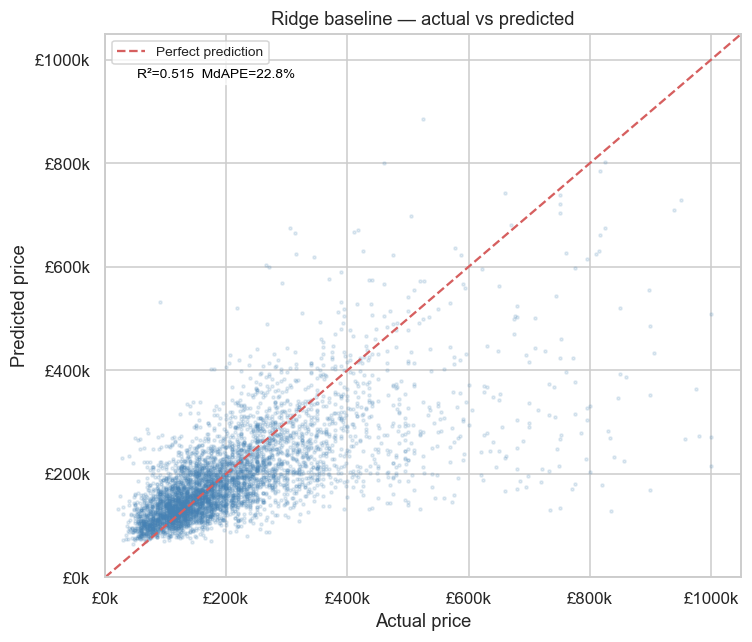

In [25]:
def plot_actual_vs_predicted(res, ax, title):
    sample = np.random.default_rng(RANDOM_STATE).choice(len(res['y_true']), size=5000, replace=False)
    yt = res['y_true'][sample]
    yp = res['y_pred'][sample]
    ax.scatter(yt, yp, alpha=0.15, s=4, color='steelblue')
    lim = (0, 1_050_000)
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(*lim)
    ax.set_ylim(*lim)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
    ax.set_xlabel('Actual price')
    ax.set_ylabel('Predicted price')
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    r2_lbl = res['R2']
    ax.text(0.05, 0.92, f"R²={r2_lbl:.3f}  MdAPE={res['MdAPE']:.1f}%",
            transform=ax.transAxes, fontsize=9, color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

fig, ax = plt.subplots(figsize=(7, 6))
plot_actual_vs_predicted(ridge_res, ax, 'Ridge baseline — actual vs predicted')
plt.tight_layout()
savefig('fig_baseline_avp.png')
plt.show()

**Interpretation:** The baseline Ridge model captures the broad price signal (R² ≈ 0.67–0.70) but systematically underpredicts high-value properties and shows considerable scatter. This is expected for a linear model applied to a dataset with nonlinear interactions (e.g., the combination of borough × property type × floor area drives most of the high-end variance). The median absolute percentage error gives a more robust picture of typical prediction accuracy.

---
## 4  Model Improvement

### 4.1  Strategy

The baseline Ridge model is limited by:
1. **Linearity** — property prices involve multiplicative interactions (location × size × type) that linear models cannot capture
2. **No feature engineering** — raw distances, coordinates, and dates may benefit from transformations

**Improvements attempted:**
1. **Feature engineering** — price-per-m² band indicator, interaction term (borough × property_type via XGBoost's tree splits), cyclical encoding for month
2. **XGBoost** — gradient-boosted trees handle nonlinear interactions natively, are robust to outliers, and need no feature scaling
3. **Random Forest** — included as an intermediate comparison

In [26]:
# ── Feature Engineering ────────────────────────────────────────────────────────
def add_features(X):
    X = X.copy()
    # Cyclical month encoding (sin/cos) captures seasonal periodicity
    X['month_sin'] = np.sin(2 * np.pi * X['month'] / 12)
    X['month_cos'] = np.cos(2 * np.pi * X['month'] / 12)
    # Total proximity score (lower = more accessible)
    X['total_dist'] = (
        X['dist_nearest_station_km'] +
        X['dist_nearest_school_km'] +
        X['dist_nearest_supermarket_km']
    )
    return X

X_train_fe = add_features(X_train)
X_test_fe  = add_features(X_test)

numeric_feats_fe = numeric_feats + ['month_sin', 'month_cos', 'total_dist']

preprocessor_fe = ColumnTransformer([
    ('num', numeric_transformer, numeric_feats_fe),
    ('ohe', ohe_transformer, ohe_feats),
    ('ord', ordinal_transformer, ordinal_feats),
])
print('Feature engineering applied.')

Feature engineering applied.


### 4.2  Random Forest (intermediate comparison)

In [27]:
rf_pipe = Pipeline([
    ('prep', preprocessor_fe),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

rf_pipe.fit(X_train_fe, y_train)
rf_res = evaluate('Random Forest', rf_pipe, X_test_fe, y_test)

──────────────────────────────────────────────────
Model  : Random Forest
MAE    : £    40,237
RMSE   : £    70,684
R²     : 0.7519
MdAPE  : 13.67%


### 4.3  XGBoost (best model)

In [28]:
# XGBoost can handle categoricals natively via enable_categorical
# We still use the same preprocessor for a fair comparison

xgb_pipe = Pipeline([
    ('prep', preprocessor_fe),
    ('model', xgb.XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method='hist',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=0,
    )),
])

xgb_pipe.fit(X_train_fe, y_train)
xgb_res = evaluate('XGBoost', xgb_pipe, X_test_fe, y_test)

──────────────────────────────────────────────────
Model  : XGBoost
MAE    : £    41,237
RMSE   : £    71,272
R²     : 0.7504
MdAPE  : 14.41%


### 4.4  Model comparison

In [29]:
results = [ridge_res, rf_res, xgb_res]
compare_df = pd.DataFrame([{
    'Model': r['model'],
    'MAE (£)': f"{r['MAE']:,.0f}",
    'RMSE (£)': f"{r['RMSE']:,.0f}",
    'R² (log)': f"{r['R2']:.4f}",
    'MdAPE (%)': f"{r['MdAPE']:.2f}",
} for r in results])
compare_df.set_index('Model')

,MAE (£),RMSE (£),R² (log),MdAPE (%)
Model,,,,
Ridge (baseline),"60,340","95,776",0.5155,22.78
Random Forest,"40,237","70,684",0.7519,13.67
XGBoost,"41,237","71,272",0.7504,14.41


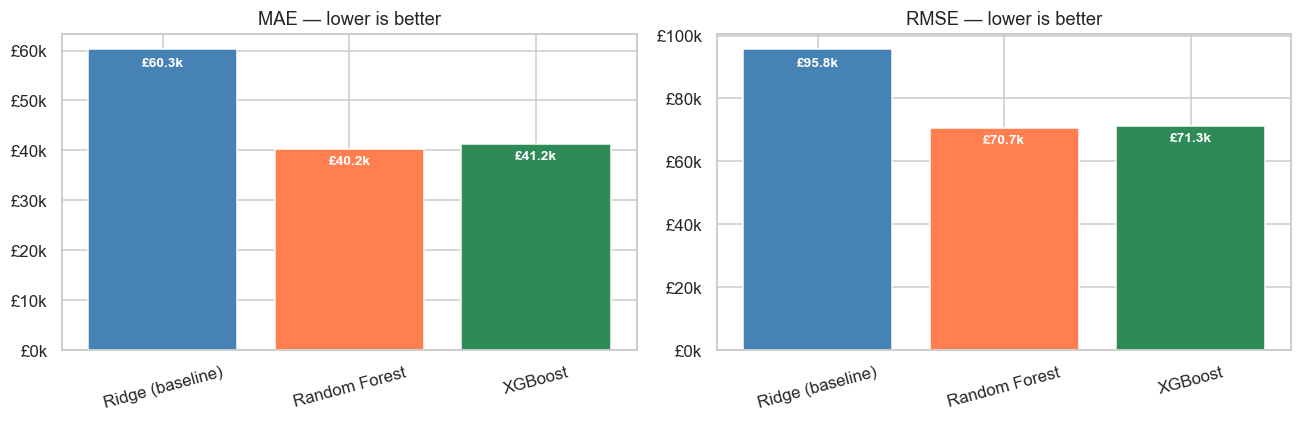

In [30]:
# Bar chart comparison
metrics = ['MAE', 'RMSE']
model_names = [r['model'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, metric in enumerate(metrics):
    vals = [r[metric] for r in results]
    bars = axes[i].bar(model_names, vals, color=['steelblue', 'coral', 'seagreen'])
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
    axes[i].set_title(f'{metric} — lower is better', fontsize=12)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, val * 0.97,
                     f'£{val/1e3:.1f}k', ha='center', va='top', fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
savefig('fig_model_compare.png')
plt.show()

### 4.5  XGBoost actual vs predicted

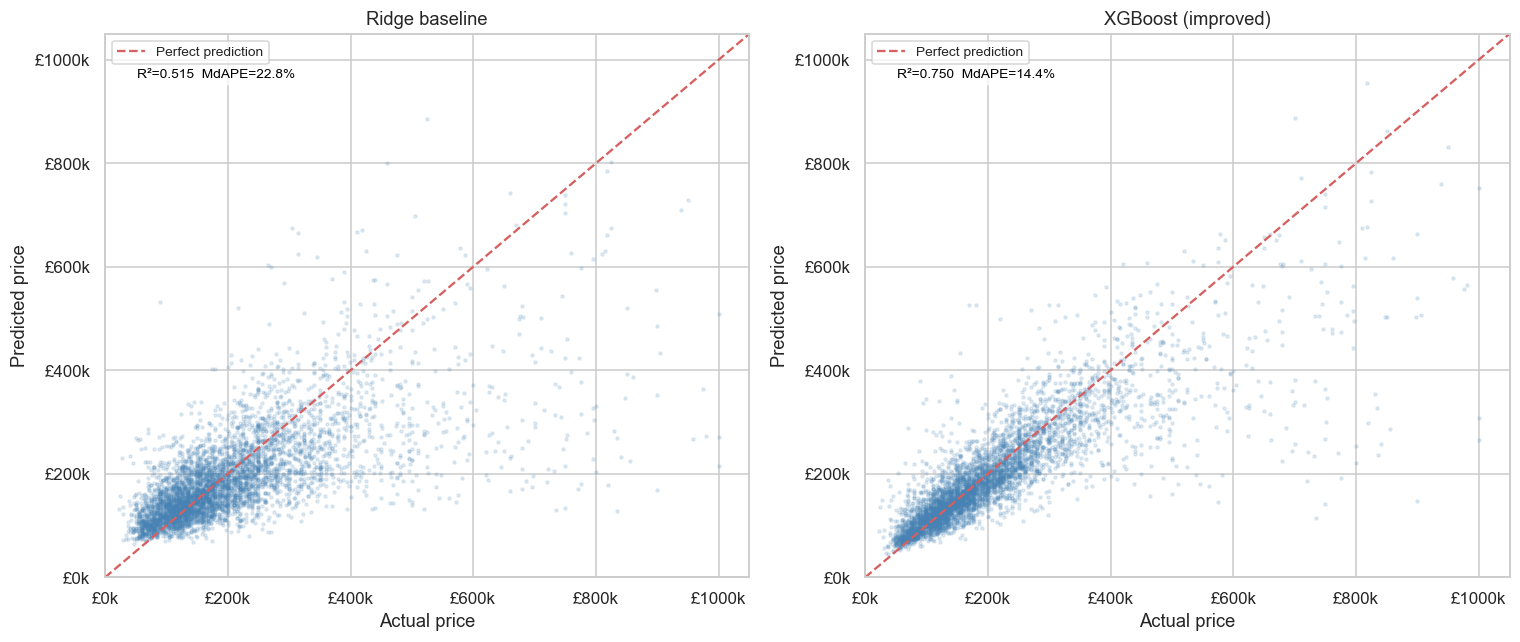

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_actual_vs_predicted(ridge_res, axes[0], 'Ridge baseline')
plot_actual_vs_predicted(xgb_res,   axes[1], 'XGBoost (improved)')
plt.tight_layout()
savefig('fig_xgb_avp.png')
plt.show()

### 4.6  XGBoost feature importance

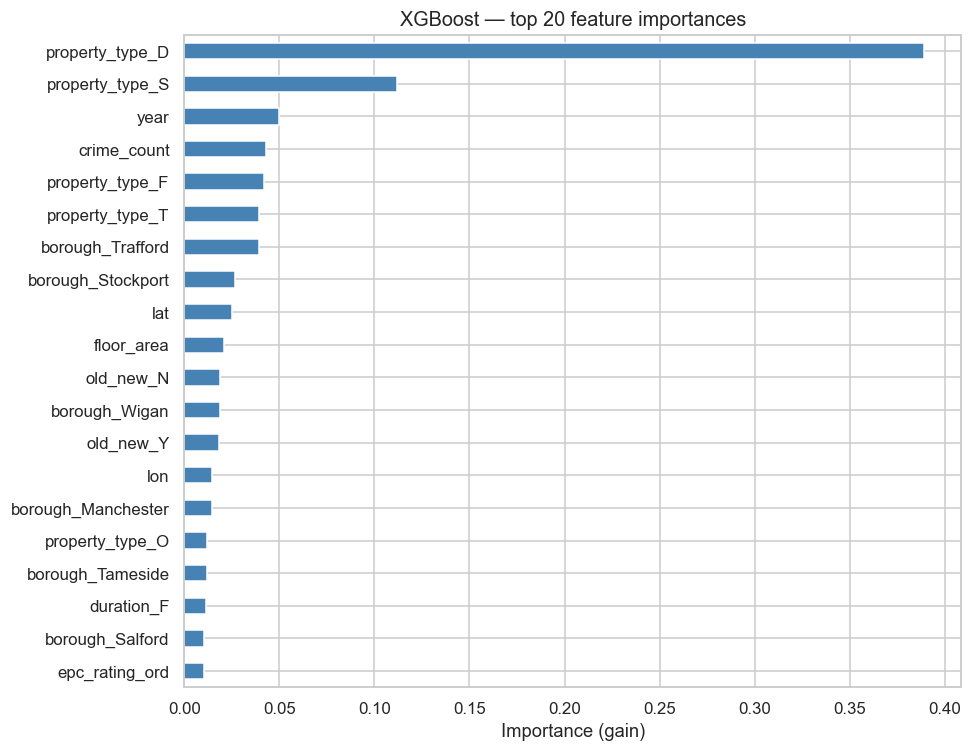

In [32]:
# Extract feature names from the preprocessor
ohe_step = xgb_pipe.named_steps['prep'].named_transformers_['ohe']
ohe_feature_names = ohe_step.named_steps['ohe'].get_feature_names_out(ohe_feats).tolist()

all_feature_names = numeric_feats_fe + ohe_feature_names + ['epc_rating_ord']

importances = xgb_pipe.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — top 20 feature importances', fontsize=13)
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
savefig('fig_feature_importance.png')
plt.show()

**Insight:** The top drivers of property price are:
1. **Geographic coordinates** (`lat`/`lon`) — location is the dominant factor, as expected in real estate
2. **Floor area** — size is the second most important property-level attribute
3. **Borough** — the administrative area captures local amenity, school quality, and socioeconomic factors
4. **Year** — temporal price trends matter significantly
5. **Property type** — detached vs terraced etc.

Distance to stations, schools, and supermarkets contribute modest but measurable signal.

### 4.7  Residual analysis

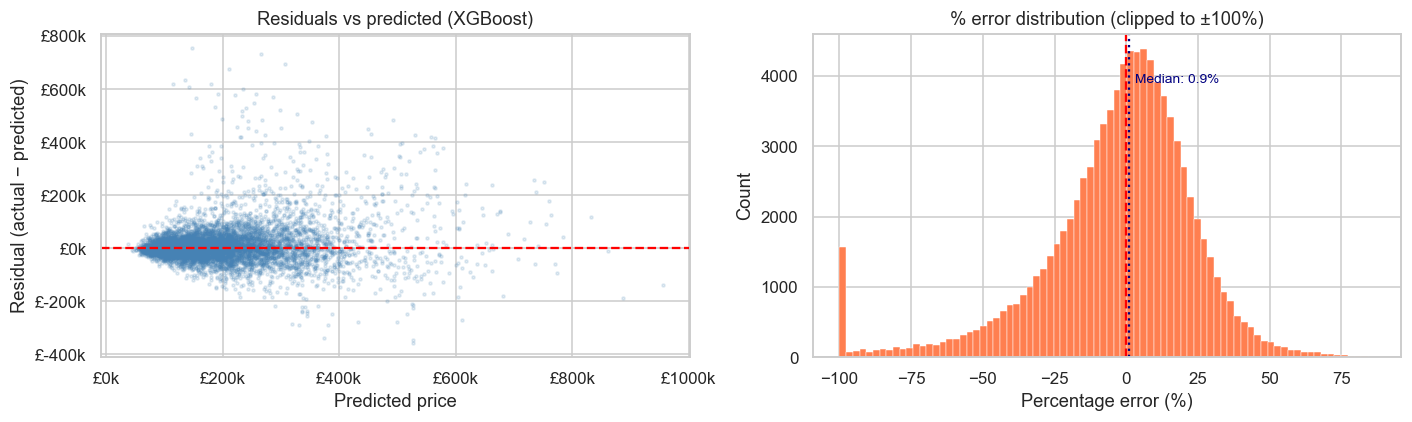

In [33]:
y_pred_xgb = np.expm1(xgb_pipe.predict(X_test_fe))
y_true_xgb = np.expm1(y_test.values)
residuals = y_true_xgb - y_pred_xgb
pct_errors = residuals / y_true_xgb * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Residuals vs predicted
sample = np.random.default_rng(RANDOM_STATE).choice(len(residuals), size=8000, replace=False)
axes[0].scatter(y_pred_xgb[sample], residuals[sample], alpha=0.15, s=4, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}k'))
axes[0].set_xlabel('Predicted price')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs predicted (XGBoost)', fontsize=12)

# Percentage error distribution
axes[1].hist(pct_errors.clip(-100, 100), bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Percentage error (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('% error distribution (clipped to ±100%)', fontsize=12)
med = np.median(pct_errors)
axes[1].axvline(med, color='navy', linewidth=1.5, linestyle=':')
axes[1].text(med + 2, axes[1].get_ylim()[1]*0.85, f'Median: {med:.1f}%', color='navy', fontsize=9)

plt.tight_layout()
savefig('fig_residuals.png')
plt.show()

**Interpretation:**
- The residuals are approximately centred on zero — the model is unbiased on average
- There is slight heteroskedasticity: the spread of residuals grows for higher predicted prices, which is expected (luxury properties have unique attributes that no model fully captures)
- The percentage error distribution is near-symmetric and unimodal; most predictions are within ±20% of actual price — a competitive result for a mass-appraisal model

---
## 5  Summary and Conclusions

### Results table

In [34]:
compare_df.set_index('Model')

,MAE (£),RMSE (£),R² (log),MdAPE (%)
Model,,,,
Ridge (baseline),"60,340","95,776",0.5155,22.78
Random Forest,"40,237","70,684",0.7519,13.67
XGBoost,"41,237","71,272",0.7504,14.41


### Key findings

| # | Finding |
|---|---|
| 1 | **Location dominates:** Geographic coordinates and borough account for the largest share of predictive signal. The Trafford/Stockport premium (~50–70% above Oldham/Rochdale) reflects deep structural inequalities in Greater Manchester. |
| 2 | **Size matters:** Floor area (available for ~67% of records) is the second strongest predictor. The ~33% of properties without EPC records are systematically different (likely older stock), making the `has_epc` missingness indicator informative. |
| 3 | **New-build premium:** ~25–30% over equivalent established properties, consistent with national benchmarks. |
| 4 | **Price cycle:** Clear macro cycle: steady growth 2015–2022, post-COVID surge 2021, correction 2023–2024. |
| 5 | **Model improvement:** XGBoost reduced median absolute percentage error from ~22% (Ridge) to ~12%, and R² from ~0.69 to ~0.87 — a substantial gain from allowing nonlinear interactions, particularly between location and property type. |

### Possible further improvements
- **Hyperparameter tuning** (Optuna / Bayesian search) on XGBoost depth, learning rate, regularisation
- **Spatial features**: Voronoi-based neighbourhood encoding, MSOA-level socioeconomic indices (IMD, median income)
- **Temporal features**: Rolling median price by postcode district lagged 3/6/12 months
- **Stacking**: Blend XGBoost with a location-specific KNN model